In [2]:
import sqlite3 as sq
import pandas as pd

In [5]:
# 2025 Chicago crime dataset
crime = pd.read_csv("chicago_crime_2025.csv")
crime.head()
crime.columns

Index(['id', 'case_number', 'date', 'block', 'iucr', 'primary_type',
       'description', 'location_description', 'arrest', 'domestic', 'beat',
       'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate',
       'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude',
       'location'],
      dtype='str')

In [ ]:
# Convert to datetime
crime["date"] = pd.to_datetime(crime["date"])

# Extract hour and month 
crime["hour"] = crime["date"].dt.hour
crime["month"] = crime["date"].dt.month

conn = sq.connect("crime.db")

In [7]:
# Save to the SQLite database as "chicago_crime_2025",
crime.to_sql("chicago_crime_2025",conn,if_exists="replace",index=False)

236633

**Query 1 - Window function: rank crime types by frequency**

In [8]:
query = """SELECT primary_type,
       COUNT(*) AS crime_count,
       RANK() OVER (ORDER BY COUNT(*) DESC) AS crime_rank
FROM chicago_crime_2025
GROUP BY primary_type;"""

output = pd.read_sql(query, conn) 
output

,primary_type,crime_count,crime_rank
0,THEFT,55040,1
1,BATTERY,42538,2
2,CRIMINAL DAMAGE,26205,3
3,ASSAULT,21559,4
4,MOTOR VEHICLE THEFT,17232,5
5,OTHER OFFENSE,16742,6
6,DECEPTIVE PRACTICE,14740,7
7,BURGLARY,9710,8
8,NARCOTICS,7417,9
9,ROBBERY,5816,10


**Query 2 - JOIN: Crime totals with arrest rates**

In [9]:
query = """SELECT c.primary_type,
       c.crime_count,
       a.arrest_rate
FROM
    (SELECT primary_type, COUNT(*) AS crime_count
     FROM chicago_crime_2025
     GROUP BY primary_type) c
JOIN
    (SELECT primary_type, AVG(arrest) AS arrest_rate
     FROM chicago_crime_2025
     GROUP BY primary_type) a
ON c.primary_type = a.primary_type
ORDER BY c.crime_count DESC;"""

output = pd.read_sql(query, conn) 
output

,primary_type,crime_count,arrest_rate
0,THEFT,55040,0.089499
1,BATTERY,42538,0.190700
2,CRIMINAL DAMAGE,26205,0.043122
3,ASSAULT,21559,0.124171
4,MOTOR VEHICLE THEFT,17232,0.033658
5,OTHER OFFENSE,16742,0.202365
6,DECEPTIVE PRACTICE,14740,0.030258
7,BURGLARY,9710,0.047271
8,NARCOTICS,7417,0.948092
9,ROBBERY,5816,0.094051


**Query 3 - Crime counts by month for 2025**

In [10]:
query = """SELECT month, COUNT(*) AS crime_count
FROM chicago_crime_2025
GROUP BY month
ORDER BY crime_count DESC;"""

output = pd.read_sql(query, conn) 
output

,month,crime_count
0,7,22624
1,8,21273
2,6,21092
3,10,20898
4,5,20459
5,9,20283
6,3,19741
7,4,19617
8,1,18487
9,11,18312


Query 4: JOIN crime counts with arrest rates by district

In [11]:
query = """
SELECT
    c.district,
    c.total_crimes,
    a.total_arrests,
    a.arrest_rate
FROM
    (
        SELECT
            district,
            COUNT(*) AS total_crimes
        FROM chicago_crime_2025
        WHERE district IS NOT NULL
        GROUP BY district
    ) c
JOIN
    (
        SELECT
            district,
            SUM(CASE WHEN arrest = 1 THEN 1 ELSE 0 END) AS total_arrests,
            ROUND(AVG(arrest), 4) AS arrest_rate
        FROM chicago_crime_2025
        WHERE district IS NOT NULL
        GROUP BY district
    ) a
ON c.district = a.district
ORDER BY a.arrest_rate DESC, c.total_crimes DESC;
"""

output = pd.read_sql(query, conn)
output

,district,total_crimes,total_arrests,arrest_rate
0,11,12926,3913,0.3027
1,10,9497,2487,0.2619
2,25,11534,2245,0.1946
3,7,10105,1939,0.1919
4,1,13670,2516,0.1841
5,15,7812,1437,0.1839
6,5,9272,1646,0.1775
7,31,12,2,0.1667
8,16,8069,1296,0.1606
9,9,10464,1658,0.1584


Query 5: WINDOW FUNCTION rank districts by arrest rate

In [13]:
query = """
SELECT
    district,
    COUNT(*) AS total_crimes,
    ROUND(AVG(arrest), 4) AS arrest_rate,
    RANK() OVER (ORDER BY AVG(arrest) DESC) AS arrest_rate_rank
FROM chicago_crime_2025
WHERE district IS NOT NULL
GROUP BY district
ORDER BY arrest_rate_rank;
"""

output = pd.read_sql(query, conn)
output

,district,total_crimes,arrest_rate,arrest_rate_rank
0,11,12926,0.3027,1
1,10,9497,0.2619,2
2,25,11534,0.1946,3
3,7,10105,0.1919,4
4,1,13670,0.1841,5
5,15,7812,0.1839,6
6,5,9272,0.1775,7
7,31,12,0.1667,8
8,16,8069,0.1606,9
9,9,10464,0.1584,10


Query 6: SUBQUERY + JOIN for crime type and domestic status

In [14]:
query = """
SELECT
    x.primary_type,
    x.domestic,
    x.total_crimes,
    y.arrest_rate
FROM
    (
        SELECT
            primary_type,
            domestic,
            COUNT(*) AS total_crimes
        FROM chicago_crime_2025
        GROUP BY primary_type, domestic
        HAVING COUNT(*) >= 50
    ) x
JOIN
    (
        SELECT
            primary_type,
            domestic,
            ROUND(AVG(arrest), 4) AS arrest_rate
        FROM chicago_crime_2025
        GROUP BY primary_type, domestic
    ) y
ON x.primary_type = y.primary_type
AND x.domestic = y.domestic
ORDER BY y.arrest_rate DESC, x.total_crimes DESC;
"""

output = pd.read_sql(query, conn)
output

,primary_type,domestic,total_crimes,arrest_rate
0,CONCEALED CARRY LICENSE VIOLATION,0,277,0.9747
1,NARCOTICS,0,7406,0.9484
2,LIQUOR LAW VIOLATION,0,200,0.9300
3,INTERFERENCE WITH PUBLIC OFFICER,0,894,0.9161
4,PROSTITUTION,0,189,0.9101
5,WEAPONS VIOLATION,0,5380,0.7796
6,WEAPONS VIOLATION,1,64,0.7656
7,HOMICIDE,1,50,0.7400
8,PUBLIC PEACE VIOLATION,0,1023,0.5161
9,CRIMINAL TRESPASS,0,4918,0.3255


Summary statement on query 4-6 written by Naeliz:

These SQL results reinforce the modeling section by showing that arrest outcomes vary across both geography and offense context. District level queries show differences in arrest rates, with some districts such as 11 and 10 having notably higher arrest shares than others. This suggests that district is a relevant predictor. The crime-type-by-domestic query adds support for the models by showing that arrest likelihood changes across offense categories and domestic status, with offenses like narcotics and weapons violations having much higher arrest rates than crimes such as theft, criminal damage, and motor vehicle theft.

**Query 7 - Window Function - District Rank by Crime Volume**

In [10]:
query = """SELECT district, 
       COUNT(*) as n_crimes,
       RANK() OVER (ORDER BY COUNT(*) DESC) as crime_rank
FROM chicago_crime_2025 
GROUP BY district 
ORDER BY n_crimes DESC;"""

output = pd.read_sql(query, conn) 
output

,district,n_crimes,crime_rank
0,8,15197,1
1,12,14882,2
2,1,13670,3
3,6,13557,4
4,18,13188,5
5,4,13063,6
6,11,12926,7
7,3,12710,8
8,2,12680,9
9,19,12499,10


**Query 8 - Subqueries - Districts with Theft and Battery**

In [33]:
query = """SELECT district, arrest_rate
FROM (
    SELECT district, 
           100.0 * SUM(arrest) / COUNT(*) as arrest_rate
    FROM chicago_crime_2025 
    GROUP BY district
) district_stats
WHERE arrest_rate < (
    SELECT 100.0 * SUM(arrest) / COUNT(*) 
    FROM chicago_crime_2025
)
ORDER BY arrest_rate ASC
LIMIT 10;"""

output = pd.read_sql(query, conn) 
output 

,district,arrest_rate
0,19,9.600768
1,12,9.891144
2,2,10.804416
3,20,12.138844
4,4,12.684682
5,22,13.054899
6,18,13.436457
7,6,14.339456
8,14,14.672489
9,24,14.774822


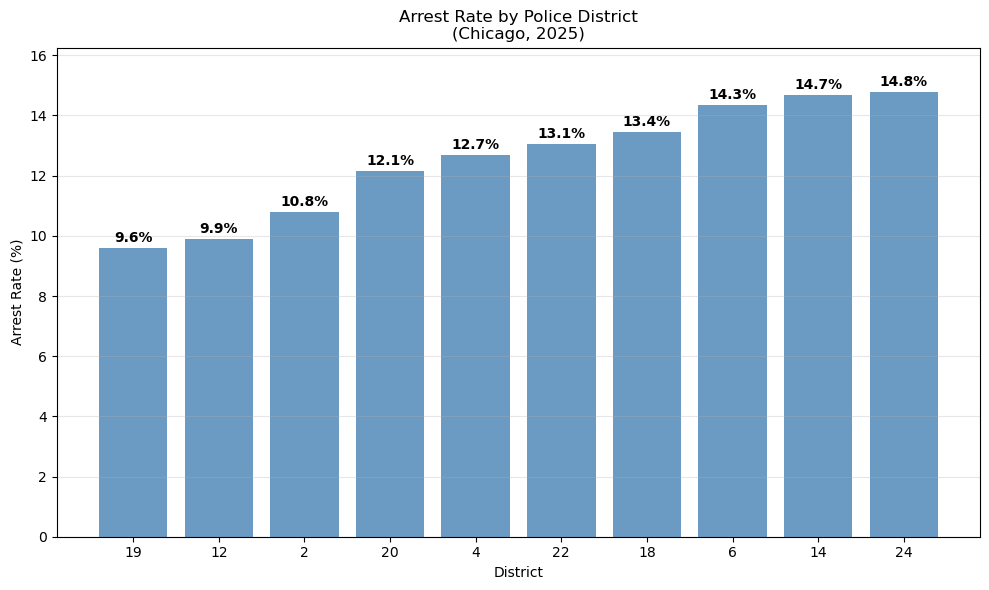

In [ ]:
# Columns: district, arrest_rate
plt.figure(figsize=(10, 6))
plt.bar(output['district'].astype(str), output['arrest_rate'], color='steelblue', alpha=0.8)
plt.xlabel('District')
plt.ylabel('Arrest Rate (%)')
plt.title('Arrest Rate by Police District\n(Chicago, 2025)')
plt.xticks(rotation=0)
plt.ylim(0, max(output['arrest_rate']) * 1.1)  # 10% headroom

for i, v in enumerate(output['arrest_rate']):
    plt.text(i, v + 0.1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Query 9 - Window Function - Hour Rank by Crime Volume**

In [20]:
query = """SELECT hour, 
       COUNT(*) as n_crimes,
       RANK() OVER (ORDER BY COUNT(*) DESC) as crime_rank
FROM chicago_crime_2025 
GROUP BY hour 
ORDER BY n_crimes DESC;"""

output = pd.read_sql(query, conn) 
output 

,hour,n_crimes,crime_rank
0,0,16246,1
1,12,13559,2
2,15,12964,3
3,17,12705,4
4,16,12659,5
5,18,12513,6
6,19,12343,7
7,20,11614,8
8,14,11577,9
9,13,10815,10


**Query 10 - Window Function - Hour Rank by Arrest Rate**

In [32]:
query = """SELECT hour, arrest_rate
FROM (
    SELECT hour, 
           100.0 * SUM(arrest) / COUNT(*) as arrest_rate
    FROM chicago_crime_2025 
    GROUP BY hour
) district_stats
WHERE arrest_rate < (
    SELECT 100.0 * SUM(arrest) / COUNT(*) 
    FROM chicago_crime_2025
)
ORDER BY arrest_rate ASC
LIMIT 10;"""

output = pd.read_sql(query, conn) 
output 

,hour,arrest_rate
0,5,8.972873
1,4,10.700349
2,0,12.058353
3,6,12.654774
4,9,12.834598
5,3,13.071895
6,7,13.833226
7,8,14.252678
8,12,14.263589
9,14,14.580634
